# CNC tool-wear detection — Anomaly detection model design

Forgewright Manufacturing, one production shift across a CNC cell. Three exports:
per-second **power**, ~2 Hz **vibration**, and the **MES production log** of jobs.
Goal: per-job mean power and peak vibration, and a ranked list of jobs that show
tool wear.

**The physics that drives every decision below.** A dull or chipped tool chatters:
it vibrates more than a healthy tool would *for the same cutting work*. Cutting work
shows up as power draw. So wear is **high vibration relative to power** — not high
vibration, and not high power. A heavy titanium cut is legitimately loud and must not
be flagged. This rules out any absolute vibration threshold from the start.

The EDA established the physics and the shape of the data. This notebook tests the
candidate architectures and picks the pair that goes into `analyse.py`.

**Architecture.** Two stages, combined with a logical AND.

* **Primary** -- a regression of vibration on cutting power plus job context. Flag
  readings whose residual exceeds **6 robust sigma**. This is the physics: how much more
  did the spindle vibrate than a healthy tool would for this much cutting work?
  Candidates: **ridge**, **Huber**, **RANSAC**.
* **Secondary** -- an unsupervised multivariate outlier detector in sensor space.
  Candidates: **Isolation Forest**, **Mahalanobis distance**, **Local Outlier Factor**.

A reading counts as anomalous only if both stages fire. A job is flagged when a
sustained share of its readings are anomalous.

**How we judge, with no answer key.** The EDA found two *independent* signals that agree
perfectly on the same 11 jobs: vibration-per-kW relative to a robust part-type baseline
(bimodal, with an empty gap) and the crest factor (perfectly separated). We reconstruct
that set here and use it as a **reference set** for comparing models. It is not ground
truth and the pipeline never uses it -- but a detector that disagrees with two
independent physical signals needs to justify itself.

**What the profile turns up**

| Issue | Evidence | Handling |
|---|---|---|
| Sensor clocks vs MES clock | sensors run 13:00–21:00 UTC, MES 08:03–13:42 naive — they barely overlap | estimate the offset from the data (section 3) |
| Sentinel power values | a handful of `9999.0` rows, vs a 0.999 quantile near 19 kW | drop via a loose IQR fence |
| Negative power | a few `-3.0` rows | drop: physically impossible |
| Duplicate readings | a few rows sharing (machine, timestamp), identical values | drop, keep first |
| Jobs with `end < start` | 3 jobs, small negative durations | transposition, not a real event → swap |
| Missing `quantity` | 3 jobs | impute with the part-type median, and record that we did |
| Vibration dropouts | two multi-minute gaps | tolerate; coverage is reported per job |

The fences are deliberately loose. A genuinely heavy titanium cut must survive; only
impossible values should go.

In [1]:
import warnings
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

DATA_DIR = "../data"
OUT_DIR = "../output"
# --- Tunables. Every decision the analysis makes, in one place. -------------- #
# Nothing here names a machine, job or date: the fleet is discovered from the data.
POWER_MIN_KW = 0.0            # negative draw is physically impossible
POWER_ABS_MAX_KW = 500.0      # hard ceiling for this class of machine
IQR_FENCE = 50.0              # very loose fence, to catch 9999-style sentinels only
CUT_FLOOR_KW = 0.5            # below this the machine is not really cutting
SIGMA_MULTIPLE = 6.0          # the 6-sigma rule for the primary detector
TRIM_SIGMA = 3.0              # trimming point for the healthy-scale estimator
CONTAMINATION = 0.15          # secondary-detector prior; see section 7
MIN_ANOM_READINGS = 5         # a job needs sustained evidence, not one spike
MIN_ANOM_FRACTION = 0.05
MIN_READINGS_VERDICT = 20     # too little data -> no verdict rather than a guess
SCORE_QUANTILE = 0.95         # wear_score = 95th percentile of residual sigma
RANDOM_STATE = 7

## 1. Load the raw exports

Timestamps first, because they turn out to be the main hazard. The sensor files carry
an explicit UTC offset (`...Z`); the MES log is naive local time. Everything is parsed
to naive-UTC here and any residual offset is *estimated from the data* in section 3 —
never assumed from a timezone rule.

In [2]:
def parse_utc(series):
    '''Parse mixed ISO timestamps to tz-naive UTC.'''
    return pd.to_datetime(series, format="mixed", utc=True, errors="coerce").dt.tz_localize(None)


def load_power(path):
    df = pd.read_csv(path)[["timestamp", "machine_id", "power_kw"]].copy()
    df["timestamp"] = parse_utc(df["timestamp"])
    df["machine_id"] = df["machine_id"].astype("string").str.strip()
    df["power_kw"] = pd.to_numeric(df["power_kw"], errors="coerce")
    return df


def load_vibration(path):
    cols = ["timestamp", "machine_id", "vibration_rms_g", "vibration_peak_g"]
    df = pd.read_csv(path)[cols].copy()
    df["timestamp"] = parse_utc(df["timestamp"])
    df["machine_id"] = df["machine_id"].astype("string").str.strip()
    for c in ("vibration_rms_g", "vibration_peak_g"):
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_production_log(path):
    df = pd.read_csv(path)
    df["machine_id"] = df["machine_id"].astype("string").str.strip()
    for c in ("start_time", "end_time"):
        df[c] = parse_utc(df[c])
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
    return df


power_raw = load_power(os.path.join(DATA_DIR, "power.csv"))
vib_raw = load_vibration(os.path.join(DATA_DIR, "vibration.csv"))
log_raw = load_production_log(os.path.join(DATA_DIR, "production_log.csv"))

## 2. Define the cleaning functions

In [3]:
def robust_upper_bound(values, iqr_multiple=IQR_FENCE):
    '''Loose upper plausibility fence, wide enough to keep real heavy cuts.'''
    v = values[np.isfinite(values)]
    if v.size == 0:
        return np.inf
    q1, q3 = np.percentile(v, [25, 75])
    return float(q3 + iqr_multiple * max(q3 - q1, 1e-9))


def clean_power(power):
    df = power.dropna(subset=["timestamp", "machine_id", "power_kw"]).copy()
    n0 = len(df)
    df = df.drop_duplicates(subset=["machine_id", "timestamp"], keep="first")
    n_dup = n0 - len(df)

    neg = df["power_kw"] < POWER_MIN_KW
    bound = min(POWER_ABS_MAX_KW, robust_upper_bound(df.loc[~neg, "power_kw"].to_numpy(float)))
    sentinel = df["power_kw"] > bound
    report = {"rows_in": len(power), "duplicates": n_dup, "negative": int(neg.sum()),
              "sentinel": int(sentinel.sum()), "sentinel_bound_kw": round(bound, 2),
              "sentinel_values": sorted(df.loc[sentinel, "power_kw"].unique().tolist())}
    df = df[~neg & ~sentinel].sort_values(["machine_id", "timestamp"]).reset_index(drop=True)
    report["rows_out"] = len(df)
    return df, report


def clean_vibration(vibration):
    cols = ["timestamp", "machine_id", "vibration_rms_g", "vibration_peak_g"]
    df = vibration.dropna(subset=cols).copy()
    n0 = len(df)
    df = df.drop_duplicates(subset=["machine_id", "timestamp"], keep="first")
    n_dup = n0 - len(df)

    bad = ((df["vibration_rms_g"] < 0) | (df["vibration_peak_g"] < 0)
           | (df["vibration_peak_g"] < df["vibration_rms_g"]))
    report = {"rows_in": len(vibration), "duplicates": n_dup, "invalid": int(bad.sum())}
    df = df[~bad]
    for col in ("vibration_rms_g", "vibration_peak_g"):
        bound = robust_upper_bound(df[col].to_numpy(float))
        report[f"sentinel_{col}"] = int((df[col] > bound).sum())
        df = df[df[col] <= bound]
    df = df.sort_values(["machine_id", "timestamp"]).reset_index(drop=True)
    report["rows_out"] = len(df)
    return df, report


def clean_production_log(log):
    df = log.dropna(subset=["start_time", "end_time"]).drop_duplicates(subset=["job_id"]).copy()
    df["notes"] = ""

    reversed_mask = df["end_time"] < df["start_time"]
    if reversed_mask.any():
        s = df.loc[reversed_mask, "start_time"].copy()
        df.loc[reversed_mask, "start_time"] = df.loc[reversed_mask, "end_time"]
        df.loc[reversed_mask, "end_time"] = s
        df.loc[reversed_mask, "notes"] = "start/end transposed in MES; swapped"

    df["duration_s"] = (df["end_time"] - df["start_time"]).dt.total_seconds()
    df = df[df["duration_s"] >= 1.0].copy()

    missing_qty = df["quantity"].isna()
    df["quantity_imputed"] = missing_qty
    if missing_qty.any():
        by_part = df.groupby("part_type")["quantity"].transform("median")
        df["quantity"] = df["quantity"].fillna(by_part).fillna(df["quantity"].median())
        df.loc[missing_qty, "notes"] = (df.loc[missing_qty, "notes"] + "; quantity imputed").str.strip("; ")

    df = df.sort_values(["machine_id", "start_time"]).reset_index(drop=True)
    report = {"rows_in": len(log), "rows_out": len(df),
              "reversed": int(reversed_mask.sum()), "quantity_imputed": int(missing_qty.sum())}

    # Overlapping jobs on one machine would make the reading->job join ambiguous.
    overlaps = []
    for _, g in df.groupby("machine_id"):
        prev_end, prev_id = None, None
        for row in g.itertuples():
            if prev_end is not None and row.start_time < prev_end:
                overlaps.append(f"{prev_id}->{row.job_id}")
            prev_end, prev_id = row.end_time, row.job_id
    report["overlapping_job_pairs"] = overlaps
    return df, report


power, power_report = clean_power(power_raw)
vib, vib_report = clean_vibration(vib_raw)
log, log_report = clean_production_log(log_raw)

for name, rep in [("power", power_report), ("vibration", vib_report), ("production_log", log_report)]:
    print(f"{name:<15} {rep}")

power           {'rows_in': 86405, 'duplicates': 5, 'negative': 3, 'sentinel': 4, 'sentinel_bound_kw': 421.29, 'sentinel_values': [9999.0], 'rows_out': 86377}
vibration       {'rows_in': 168969, 'duplicates': 8, 'invalid': 0, 'sentinel_vibration_rms_g': 0, 'sentinel_vibration_peak_g': 0, 'rows_out': 168961}
production_log  {'rows_in': 94, 'rows_out': 94, 'reversed': 3, 'quantity_imputed': 3, 'overlapping_job_pairs': []}


## 3. Recovering the clock offset from the data

The hint in the brief is that sensor timestamps should fall between a job's `start_time`
and `end_time`. As loaded, they mostly don't. Rather than assume "UTC+5", **estimate**
the offset with a physical objective: cutting draws power and idling does not, so the
correct offset is the one that maximises *in-job minus out-of-job* mean power. Coarse
hourly sweep, then a fine one-minute sweep.

Why this matters for generalisation: a held-out shift from other machines may carry a
different offset, and this discovers it instead of hardcoding one.

In [4]:
def in_job_mask(timestamps, jobs, shift_s=0.0):
    '''Boolean mask: does each timestamp fall inside any of this machine's job windows?'''
    shift = pd.to_timedelta(shift_s, unit="s")
    inside = np.zeros(len(timestamps), dtype=bool)
    starts = (jobs["start_time"] + shift).to_numpy()
    ends = (jobs["end_time"] + shift).to_numpy()
    for s, e in zip(starts, ends):
        inside |= (timestamps >= s) & (timestamps <= e)
    return inside


def coverage_separation(power_df, jobs_df, offset_s):
    '''Mean in-job minus out-of-job power lift, averaged over machines.'''
    seps = []
    for machine, g in power_df.groupby("machine_id", observed=True):
        jobs = jobs_df[jobs_df["machine_id"] == machine]
        if jobs.empty:
            continue
        inside = in_job_mask(g["timestamp"].to_numpy(), jobs, offset_s)
        if inside.all() or not inside.any():
            continue
        p = g["power_kw"].to_numpy(float)
        seps.append(float(p[inside].mean() - p[~inside].mean()))
    return float(np.mean(seps)) if seps else -np.inf


def estimate_clock_offset(power_df, jobs_df, coarse_range_h=14, fine_window_s=3600, fine_step_s=60):
    coarse = {h * 3600: coverage_separation(power_df, jobs_df, h * 3600)
              for h in range(-coarse_range_h, coarse_range_h + 1)}
    best_coarse = max(coarse, key=coarse.get)
    fine = {best_coarse + s: coverage_separation(power_df, jobs_df, best_coarse + s)
            for s in range(-fine_window_s, fine_window_s + 1, fine_step_s)}
    best = max(fine, key=fine.get)
    return best, coarse, fine


offset_s, coarse_scores, fine_scores = estimate_clock_offset(power, log)

print("hourly sweep (power lift in kW):")
for off, score in sorted(coarse_scores.items()):
    if np.isfinite(score):
        marker = "  <== best" if off == max(coarse_scores, key=coarse_scores.get) else ""
        print(f"  {off / 3600:+.0f} h -> {score:+.3f}{marker}")
print(f"\nchosen offset: {offset_s / 3600:+.2f} h ({offset_s:+.0f} s)")
print(f"power lift at 0 h: {coarse_scores.get(0, float('nan')):+.3f} kW -> "
      f"at chosen offset: {fine_scores[offset_s]:+.3f} kW")

# Do the machines agree independently? If they didn't, a single global shift would be wrong.
per_machine = {}
for machine in sorted(power["machine_id"].unique()):
    pm = power[power["machine_id"] == machine]
    lm = log[log["machine_id"] == machine]
    scores = {h * 3600: coverage_separation(pm, lm, h * 3600) for h in range(-14, 15)}
    per_machine[machine] = max(scores, key=scores.get) / 3600
print(f"per-machine best offset (h): {per_machine}")
print(f"all machines agree: {len(set(per_machine.values())) == 1}")

log["start_time_aligned"] = log["start_time"] + pd.to_timedelta(offset_s, unit="s")
log["end_time_aligned"] = log["end_time"] + pd.to_timedelta(offset_s, unit="s")

hourly sweep (power lift in kW):
  +0 h -> -1.348
  +1 h -> +0.498
  +2 h -> +2.407
  +3 h -> +2.979
  +4 h -> +3.888
  +5 h -> +8.377  <== best
  +6 h -> +2.249
  +7 h -> -0.109
  +8 h -> -2.060
  +9 h -> -4.381
  +10 h -> -4.927
  +11 h -> -4.985
  +12 h -> -4.457

chosen offset: +5.00 h (+18000 s)
power lift at 0 h: -1.348 kW -> at chosen offset: +8.377 kW
per-machine best offset (h): {'CNC-07': 5.0, 'CNC-09': 5.0, 'CNC-11': 5.0}
all machines agree: True


## 4. Join readings to jobs, and measure idle draw

Three steps:

1. **Label** each reading with the job running on its machine at that instant — a
   per-machine `searchsorted` over job starts, no assumptions about naming or ordering.
2. **Pair** each vibration reading with the nearest power reading. Vibration logs ~2 Hz
   and power ~1 Hz, so `merge_asof` with a 1 s tolerance matches them at native
   resolution instead of resampling onto an arbitrary grid — which matters because the
   deliverable needs the *peak* vibration.
3. **Idle baseline** per machine, measured on readings *outside* every job window. The
   brief defines mean job power as net of this idle draw.

Readings outside all job windows are exactly what makes the idle estimate possible, so
they're kept rather than discarded.

In [5]:
def assign_jobs(readings, jobs_df):
    '''Label each reading with its job_id (NA when the machine is between jobs).'''
    out = readings.copy()
    out["job_id"] = pd.Series(pd.NA, index=out.index, dtype="string")
    for machine, jobs in jobs_df.groupby("machine_id", observed=True):
        mask = (out["machine_id"] == machine).to_numpy()
        if not mask.any():
            continue
        jobs = jobs.sort_values("start_time_aligned")
        starts = jobs["start_time_aligned"].to_numpy()
        ends = jobs["end_time_aligned"].to_numpy()
        ids = jobs["job_id"].to_numpy()

        t = out.loc[mask, "timestamp"].to_numpy()
        pos = np.searchsorted(starts, t, side="right") - 1
        valid = (pos >= 0) & (t <= ends[np.clip(pos, 0, len(ends) - 1)])
        labels = np.full(len(t), None, dtype=object)
        labels[valid] = ids[pos[valid]]
        out.iloc[np.flatnonzero(mask), out.columns.get_loc("job_id")] = pd.array(labels, dtype="string")
    return out


def pair_vibration_with_power(vibration, power_df, tolerance_s=1.0):
    '''Nearest-in-time power reading for each vibration reading, per machine.'''
    return pd.merge_asof(
        vibration.sort_values("timestamp"),
        power_df[["timestamp", "machine_id", "power_kw"]].sort_values("timestamp"),
        on="timestamp", by="machine_id", direction="nearest",
        tolerance=pd.Timedelta(seconds=tolerance_s),
    )


def estimate_idle_baseline(power_with_jobs):
    '''Minimum power draw per machine while no job is running.'''
    idle = power_with_jobs[power_with_jobs["job_id"].isna()]
    baseline = idle.groupby("machine_id", observed=True)["power_kw"].min()
    machines = pd.Index(sorted(power_with_jobs["machine_id"].unique()), name="machine_id")
    fallback = float(idle["power_kw"].min()) if len(idle) else 0.0
    return baseline.reindex(machines).fillna(fallback)


power = assign_jobs(power, log)
vib = assign_jobs(vib, log)
idle_baseline = estimate_idle_baseline(power)
paired = pair_vibration_with_power(vib, power)

print(f"power readings inside a job:     {power['job_id'].notna().sum():,} of {len(power):,}"
      f" ({100 * power['job_id'].notna().mean():.1f}%)")
print(f"vibration readings inside a job: {vib['job_id'].notna().sum():,} of {len(vib):,}"
      f" ({100 * vib['job_id'].notna().mean():.1f}%)")
print(f"jobs with at least one power reading: {power['job_id'].nunique()} of {len(log)}")
print(f"vibration rows with no power within 1 s: {int(paired['power_kw'].isna().sum()):,}")
print(f"\nidle baseline (kW):\n{idle_baseline.round(3).to_string()}")

power readings inside a job:     39,350 of 86,377 (45.6%)
vibration readings inside a job: 75,689 of 168,961 (44.8%)
jobs with at least one power reading: 94 of 94
vibration rows with no power within 1 s: 199

idle baseline (kW):
machine_id
CNC-07    0.290
CNC-09    0.302
CNC-11    0.321


## 5. Features, and the shape of the vibration/power relationship

The key derived quantity is **vibration per net kW** — the raw physical ratio behind the
whole exercise.

The scatter below shows vibration rising with power *multiplicatively*: spread widens
with the level. So the model is fitted in **log space**, where `log(rms) ~ log(net power)`
makes the error additive and roughly homoscedastic. Without it, one sigma cannot serve
both a 3 kW aluminium cut and a 15 kW titanium cut — and a residual in logs reads
directly as *"x% more vibration than a healthy tool would give"*.

Readings below `CUT_FLOOR_KW` are dropped: inside a job window a machine still spends
time not really cutting, where the ratio explodes on a near-zero denominator.

In [6]:
def build_reading_table(paired_df, jobs_df, idle):
    '''One row per in-job vibration reading, joined to power and job context.'''
    df = paired_df[paired_df["job_id"].notna() & paired_df["power_kw"].notna()].copy()
    df = df.merge(jobs_df[["job_id", "part_type", "operator", "quantity", "duration_s"]],
                  on="job_id", how="left", validate="many_to_one")

    df["idle_baseline_kw"] = df["machine_id"].map(idle).astype(float)
    df["net_power_kw"] = (df["power_kw"] - df["idle_baseline_kw"]).clip(lower=0.0)
    df["vib_per_kw"] = df["vibration_rms_g"] / df["net_power_kw"].clip(lower=0.05)
    df["peak_to_rms"] = df["vibration_peak_g"] / df["vibration_rms_g"].clip(lower=1e-6)

    df["log_net_power_kw"] = np.log(df["net_power_kw"].clip(lower=0.05))
    df["log_vibration_rms_g"] = np.log(df["vibration_rms_g"].clip(lower=1e-4))
    df["log_vib_per_kw"] = df["log_vibration_rms_g"] - df["log_net_power_kw"]
    return df.reset_index(drop=True)

In [7]:
readings = build_reading_table(paired, log, idle_baseline)
cutting = readings[readings["net_power_kw"] >= CUT_FLOOR_KW].reset_index(drop=True)

print(f"in-job readings {len(readings):,} -> cutting readings {len(cutting):,} "
      f"across {cutting['job_id'].nunique()} jobs")
print(f"machines: {sorted(cutting['machine_id'].unique())}")
print(f"part types: {sorted(cutting['part_type'].dropna().unique())}")

# Quantify the heteroscedasticity that justifies the log target.
for label, col in [("additive", "vibration_rms_g"), ("log", "log_vibration_rms_g")]:
    sextile = pd.qcut(cutting["net_power_kw"], 6, labels=False, duplicates="drop")
    spread = cutting.groupby(sextile)[col].std()
    print(f"{label:>9} target: residual-proxy spread across power sextiles "
          f"varies {spread.max() / spread.min():.2f}x")

in-job readings 75,689 -> cutting readings 73,379 across 91 jobs
machines: ['CNC-07', 'CNC-09', 'CNC-11']
part types: ['AL-bracket', 'AL-panel', 'ST-gear', 'ST-housing', 'TI-fitting']
 additive target: residual-proxy spread across power sextiles varies 2.31x
      log target: residual-proxy spread across power sextiles varies 1.42x


## 6. A reference set, for validation only

There is no ground-truth wear label, so any claim about accuracy needs an independent
yardstick. Two signals:

1. **Vibration-per-kW relative to a robust part-type baseline.** The baseline is
   estimated *iteratively* — take the median ratio, drop jobs more than 10% above it,
   re-estimate — because a plain cohort median is contaminated wherever several jobs in
   a small cohort are worn, which drags the baseline up and hides them.
2. **Crest factor** (`peak / rms`). Chatter is impulsive, so it lifts peak more than rms.
   The primary detector never sees `peak_to_rms`, so this is a genuinely separate axis.

This is a *derived* reference, not truth: it encodes the same physics as the detector, so
agreement is a consistency check, not proof. **It is never used for fitting.**

robust part-type baseline (g per net kW):
part_type
AL-bracket    0.04895
AL-panel      0.04532
ST-gear       0.04137
ST-housing    0.04024
TI-fitting    0.03887

reference-worn jobs: 11 of 91
 job_id machine_id  part_type    n   ratio  crest   rel  reference_worn
JOB-007     CNC-07 ST-housing  768 0.07436  4.581 1.848            True
JOB-120     CNC-09   AL-panel 1414 0.08283  4.789 1.828            True
JOB-024     CNC-07    ST-gear  386 0.07396  4.583 1.788            True
JOB-106     CNC-09 AL-bracket 1256 0.08590  4.764 1.755            True
JOB-104     CNC-09 TI-fitting 1275 0.06792  4.785 1.747            True
JOB-206     CNC-11 ST-housing  345 0.06773  4.747 1.683            True
JOB-210     CNC-11 AL-bracket  512 0.08191  4.745 1.673            True
JOB-224     CNC-11   AL-panel  990 0.07560  4.761 1.668            True
JOB-032     CNC-07 ST-housing  445 0.06416  4.546 1.594            True
JOB-040     CNC-07 ST-housing  991 0.06395  4.583 1.589            True
JOB-018     CNC

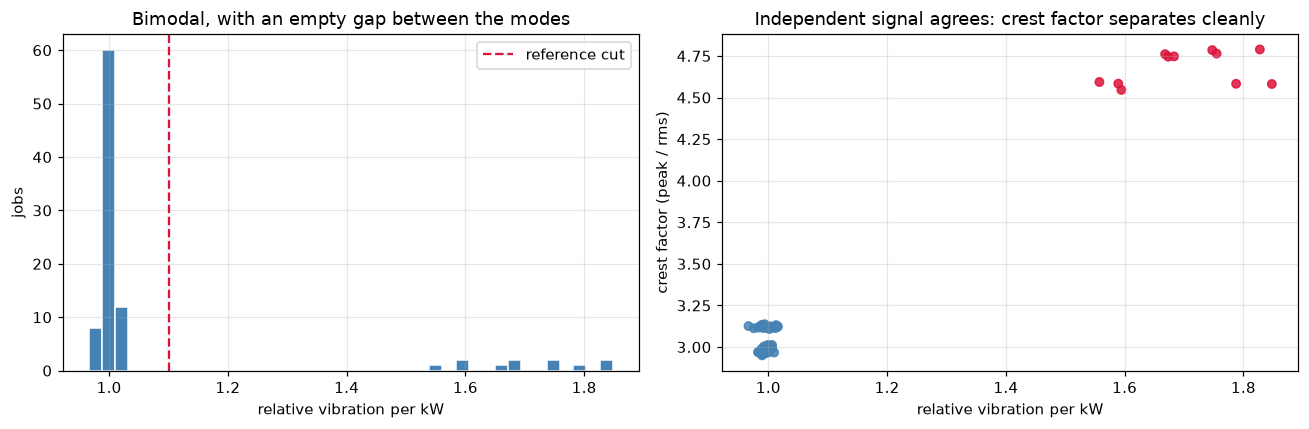

In [8]:
def derive_reference_set(cutting_df, threshold=1.10, max_iter=10):
    '''Jobs whose vibration-per-kW sits above a robustly-estimated part-type baseline.'''
    per_job = cutting_df.groupby("job_id", observed=True).agg(
        machine_id=("machine_id", "first"),
        part_type=("part_type", "first"),
        n=("vib_per_kw", "size"),
        ratio=("vib_per_kw", "median"),
        crest=("peak_to_rms", "median"),
    ).reset_index()

    base = per_job.groupby("part_type")["ratio"].median()
    for _ in range(max_iter):
        rel = per_job["ratio"] / per_job["part_type"].map(base)
        healthy = per_job[rel < threshold]
        new_base = healthy.groupby("part_type")["ratio"].median().reindex(base.index).fillna(base)
        if new_base.sub(base).abs().max() < 1e-12:
            break
        base = new_base

    per_job["rel"] = per_job["ratio"] / per_job["part_type"].map(base)
    per_job["reference_worn"] = per_job["rel"] >= threshold
    return per_job.sort_values("rel", ascending=False), base


reference, part_baseline = derive_reference_set(cutting)
reference_worn = set(reference.loc[reference["reference_worn"], "job_id"])
worn_reading_mask = cutting["job_id"].isin(reference_worn).to_numpy()

print("robust part-type baseline (g per net kW):")
print(part_baseline.round(5).to_string())
print(f"\nreference-worn jobs: {len(reference_worn)} of {len(reference)}")
print(reference[reference["reference_worn"]]
      .round({"ratio": 5, "crest": 3, "rel": 3}).to_string(index=False))

healthy, worn = reference[~reference["reference_worn"]], reference[reference["reference_worn"]]
print(f"\nhealthy rel: {healthy['rel'].min():.3f}-{healthy['rel'].max():.3f} "
      f"(sd {healthy['rel'].std():.4f}) | worn rel from {worn['rel'].min():.3f}")
print(f"crest factor -- healthy max {healthy['crest'].max():.3f} | worn min {worn['crest'].min():.3f} "
      f"| clean separation: {healthy['crest'].max() < worn['crest'].min()}")
print(f"affected share of cutting readings: {100 * worn_reading_mask.mean():.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(reference["rel"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(1.10, color="crimson", ls="--", label="reference cut")
axes[0].set(xlabel="relative vibration per kW", ylabel="jobs",
            title="Bimodal, with an empty gap between the modes")
axes[0].legend()
axes[1].scatter(reference["rel"], reference["crest"],
                c=np.where(reference["reference_worn"], "crimson", "steelblue"), s=30, alpha=0.85)
axes[1].set(xlabel="relative vibration per kW", ylabel="crest factor (peak / rms)",
            title="Independent signal agrees: crest factor separates cleanly")
plt.tight_layout()

## 7. The detector: two stages, combined with AND

| Stage | Question | Implementation |
|---|---|---|
| Primary (physics-informed) | Is vibration higher than this power/machine/material predicts? | `Pipeline(ColumnTransformer, Ridge \| HuberRegressor \| RANSACRegressor)`, 6σ on robust residuals |
| Secondary (unsupervised) | Is this reading an outlier in raw sensor space? | `Pipeline(StandardScaler, IsolationForest \| EllipticEnvelope \| LocalOutlierFactor)` |

Requiring both to agree suppresses single-model artefacts, at some cost in sensitivity.

**Why `sklearn.pipeline`.** One-hot encoding, scaling and interactions become a declarative
`ColumnTransformer`, so each candidate is a single object that fits on the raw reading
DataFrame — no hand-assembled matrix, no separately-persisted encoder, no train/score
column drift. Crucially, cross-validation then refits the *whole* preprocessing chain
inside each fold, which is the only honest way to cross-validate a fitted encoder.
`handle_unknown="ignore"` lets a saved model score a shift with unfamiliar machines:
unseen levels encode as zeros and fall back to the global slope rather than raising.

**One custom transformer.** `NumericByCategory` multiplies log-power by the one-hot levels
of machine and part type, giving each its own vibration-vs-power slope — the thing that
stops an aggressive titanium cut looking like chatter. It's written by hand because it
multiplies *across* two `ColumnTransformer` branches, which `ColumnTransformer` can't
express. Deliberately **not** `PolynomialFeatures(interaction_only=True)`: that would also
create `machine × part_type` terms, and since worn jobs cluster in those cells (3 of 5
CNC-07 ST-housing jobs are worn) such a term would absorb the very signal we want into
the baseline.

**The scale estimator matters as much as the model.** Using the sample standard deviation
would be circular — chattering readings widen σ and hide themselves. Even a plain MAD is
computed over healthy *and* worn readings, and at ~13% contamination it still overstates
healthy scatter, raising the 6σ bar and making the detector under-sensitive. So: estimate,
discard beyond 3σ, re-estimate, until it converges on the *healthy* scatter.

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import HuberRegressor, LinearRegression, RANSACRegressor, Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET = "log_vibration_rms_g"
NUMERIC_FEATURES = ["log_net_power_kw", "quantity"]
CATEGORICAL_FEATURES = ["machine_id", "part_type"]
INTERACTIONS = [("log_net_power_kw", "machine_id"), ("log_net_power_kw", "part_type")]
SECONDARY_FEATURES = ["log_net_power_kw", "log_vib_per_kw", "peak_to_rms"]

# The two competing functional forms, compared head-to-head in section 8.
LOG_FORM = {
    "target": "log_vibration_rms_g",
    "numeric": ["log_net_power_kw", "quantity"],
    "interactions": [("log_net_power_kw", "machine_id"), ("log_net_power_kw", "part_type")],
}
ADDITIVE_FORM = {
    "target": "vibration_rms_g",
    "numeric": ["net_power_kw", "quantity"],
    "interactions": [("net_power_kw", "machine_id"), ("net_power_kw", "part_type")],
}


class NumericByCategory(BaseEstimator, TransformerMixin):
    '''Products of a numeric column with the one-hot levels of a categorical column.

    Gives each machine and material its own vibration-vs-power slope. Unseen levels
    at scoring time produce zeros, falling back to the global slope.
    '''

    def __init__(self, pairs=()):
        self.pairs = pairs

    def fit(self, X, y=None):
        self.pairs_ = [tuple(p) for p in (self.pairs or []) if len(p) == 2]
        self.levels_ = {}
        for _, cat in self.pairs_:
            if cat not in self.levels_:
                # drop the first level for identifiability: it is the reference slope
                self.levels_[cat] = sorted(X[cat].dropna().unique().tolist())[1:]
        self.feature_names_out_ = [f"{num}:{cat}={lvl}" for num, cat in self.pairs_
                                   for lvl in self.levels_[cat]]
        return self

    def transform(self, X):
        cols = []
        for num, cat in self.pairs_:
            values = pd.to_numeric(X[num], errors="coerce").fillna(0.0).to_numpy(float)
            for lvl in self.levels_[cat]:
                cols.append(values * (X[cat] == lvl).to_numpy(float))
        return np.column_stack(cols) if cols else np.zeros((len(X), 0))

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_out_, dtype=object)


def make_design(numeric_features=NUMERIC_FEATURES, interactions=INTERACTIONS):
    '''Declarative design matrix: scaled numerics | one-hot categoricals | interactions.'''
    return ColumnTransformer(
        [
            ("num", StandardScaler(), list(numeric_features)),
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
             CATEGORICAL_FEATURES),
            ("inter", NumericByCategory(interactions),
             list(dict.fromkeys(list(numeric_features) + CATEGORICAL_FEATURES))),
        ],
        remainder="drop", verbose_feature_names_out=False,
    )


def make_primary(name, numeric_features=NUMERIC_FEATURES, interactions=INTERACTIONS):
    estimators = {
        "ridge": lambda: Ridge(alpha=1.0),
        "huber": lambda: HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=300),
        "ransac": lambda: RANSACRegressor(estimator=LinearRegression(), min_samples=0.15,
                                          max_trials=120, random_state=RANDOM_STATE),
    }
    return Pipeline([("design", make_design(numeric_features, interactions)),
                     ("model", estimators[name]())])


def make_secondary(name, contamination=CONTAMINATION):
    detectors = {
        "isolation_forest": lambda: IsolationForest(n_estimators=100, max_samples=256,
                                                   contamination=contamination,
                                                   random_state=RANDOM_STATE, n_jobs=-1),
        "mahalanobis": lambda: EllipticEnvelope(contamination=contamination,
                                                support_fraction=0.75, random_state=RANDOM_STATE),
        "lof": lambda: LocalOutlierFactor(n_neighbors=20, contamination=contamination,
                                          novelty=True),
    }
    return Pipeline([("scale", StandardScaler()), ("detector", detectors[name]())])


def robust_scale(residuals, trim_sigma=TRIM_SIGMA, max_iter=20):
    '''Scatter of the HEALTHY residuals: iteratively trimmed MAD.'''
    r = residuals[np.isfinite(residuals)]
    if r.size == 0:
        return 1e-9
    centre = float(np.median(r))
    scale = max(float(1.4826 * np.median(np.abs(r - centre))), 1e-9)
    for _ in range(max_iter):
        keep = np.abs(r - centre) <= trim_sigma * scale
        if keep.sum() < max(30, 0.2 * r.size):
            break
        kept = r[keep]
        new_centre = float(np.median(kept))
        new_scale = max(float(1.4826 * np.median(np.abs(kept - new_centre))), 1e-9)
        if abs(new_scale - scale) <= 1e-12 * max(scale, 1.0):
            centre, scale = new_centre, new_scale
            break
        centre, scale = new_centre, new_scale
    return scale


# Inspect the design matrix before fitting anything to it.
design = make_design()
X_design = design.fit_transform(cutting)
feature_names = list(design.get_feature_names_out())
print(f"design matrix: {X_design.shape[0]:,} rows x {X_design.shape[1]} features")
print("  " + "\n  ".join(feature_names))

design matrix: 73,379 rows x 14 features
  log_net_power_kw
  quantity
  machine_id_CNC-09
  machine_id_CNC-11
  part_type_AL-panel
  part_type_ST-gear
  part_type_ST-housing
  part_type_TI-fitting
  log_net_power_kw:machine_id=CNC-09
  log_net_power_kw:machine_id=CNC-11
  log_net_power_kw:part_type=AL-panel
  log_net_power_kw:part_type=ST-gear
  log_net_power_kw:part_type=ST-housing
  log_net_power_kw:part_type=TI-fitting


## 8. Multiplicative or additive? Test it, don't assume it

Before comparing regressors, settle the functional form. In the NumPy version of this
analysis this choice mattered **far more than the choice of regressor**, so it deserves an
explicit head-to-head rather than an appeal to the scatter plot above.

* **Additive** — `rms ~ net_power`: a worn tool adds a fixed number of g, whatever the cut.
* **Multiplicative** — `log(rms) ~ log(net_power)`: a worn tool adds a fixed *percentage*.

Both are fitted with the same `Pipeline`, differing only in which columns feed it, and
judged on what a 6σ rule actually requires: **residual spread that does not depend on
power**. Two traps in reading the table:

* **Higher R² is not better here.** The additive form will score better, partly because it
  is fitted to a target with a fatter dynamic range. We are not forecasting vibration; we
  want a *healthy baseline* whose residuals expose wear.
* **`sd/MAD` is not the discriminator.** It is large in both forms, because the worn
  population is the tail — that ratio is a measure of the signal, not of misspecification.
  The column that decides the question is `resid_sd_across_power`: the ratio of residual
  standard deviation between the highest- and lowest-power sextiles. A value near 1 means
  one σ is valid everywhere; a large value means a single threshold is simultaneously too
  loose for light aluminium cuts and too tight for heavy titanium ones.

In [10]:
form_rows, form_resid = [], {}
sextile = pd.qcut(cutting["net_power_kw"], 6, labels=False, duplicates="drop").to_numpy()

for form_name, form in [("additive", ADDITIVE_FORM), ("log", LOG_FORM)]:
    y_form = cutting[form["target"]].to_numpy(float)
    for name in ["ridge", "huber", "ransac"]:
        pipe = make_primary(name, form["numeric"], form["interactions"]).fit(cutting, y_form)
        resid = y_form - pipe.predict(cutting)
        form_resid[(form_name, name)] = resid

        centre = float(np.median(resid))
        # Plain MAD deliberately: the trimmed estimator is introduced in section 9, and
        # using it here would confound the form comparison with the scale comparison.
        s_mad = max(float(1.4826 * np.median(np.abs(resid - centre))), 1e-12)
        z = (resid - centre) / s_mad
        spread = pd.Series(resid).groupby(sextile, observed=True).std()

        form_rows.append({
            "form": form_name, "model": name,
            "r2": 1 - np.sum(resid ** 2) / np.sum((y_form - y_form.mean()) ** 2),
            "sigma_mad": s_mad, "sigma_sd": float(resid.std()),
            "sd_over_mad": float(resid.std()) / s_mad,
            "resid_sd_across_power": float(spread.max() / spread.min()),
            "pct_over_6sig": 100 * float((z >= SIGMA_MULTIPLE).mean()),
            "worn_recall": float((z[worn_reading_mask] >= SIGMA_MULTIPLE).mean()),
            "healthy_fp": float((z[~worn_reading_mask] >= SIGMA_MULTIPLE).mean()),
        })

form_table = pd.DataFrame(form_rows)
print(form_table.round(4).to_string(index=False))

for form_name in ("additive", "log"):
    sub = form_table[form_table["form"] == form_name]
    print(f"\n{form_name:>9}: mean R2 {sub['r2'].mean():.3f} | "
          f"residual sd varies {sub['resid_sd_across_power'].mean():.2f}x across power sextiles")

/Users/sysadmin/Desktop/forgewright/.venv/lib/python3.14/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


    form  model     r2  sigma_mad  sigma_sd  sd_over_mad  resid_sd_across_power  pct_over_6sig  worn_recall  healthy_fp
additive  ridge 0.5960     0.0471    0.1174       2.4928                 2.1112         3.2939       0.2485      0.0013
additive  huber 0.5698     0.0320    0.1205       3.7613                 2.1357         6.9557       0.5269      0.0023
additive ransac 0.5660     0.0355    0.1213       3.4170                 2.1951         6.2470       0.4734      0.0021
     log  ridge 0.3731     0.1492    0.4705       3.1535                 1.3951         0.0300       0.0022      0.0000
     log  huber 0.3487     0.0915    0.4782       5.2265                 1.3940         4.0298       0.3031      0.0017
     log ransac 0.3492     0.0971    0.4779       4.9203                 1.4037         2.6697       0.1981      0.0015

 additive: mean R2 0.577 | residual sd varies 2.15x across power sextiles

      log: mean R2 0.357 | residual sd varies 1.40x across power sextiles


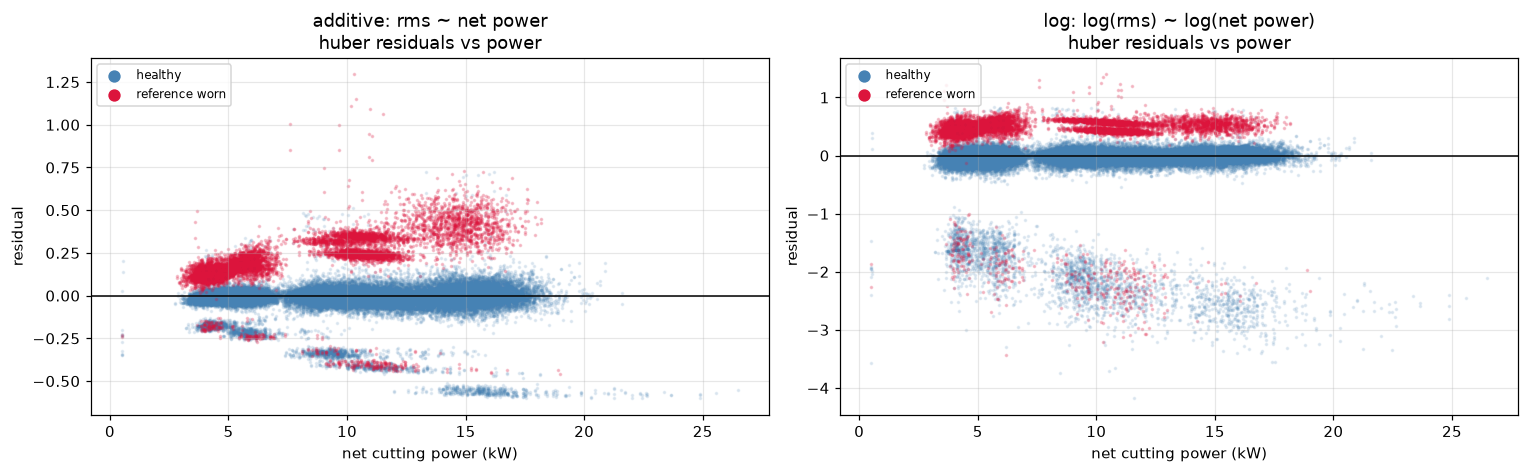

In [11]:
# The picture behind the numbers: does residual spread fan out with power?
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), sharey=False)
for ax, (form_name, label) in zip(axes, [("additive", "additive: rms ~ net power"),
                                         ("log", "log: log(rms) ~ log(net power)")]):
    resid = form_resid[(form_name, "huber")]
    ax.scatter(cutting["net_power_kw"][~worn_reading_mask], resid[~worn_reading_mask],
               s=2, alpha=0.12, color="steelblue", label="healthy")
    ax.scatter(cutting["net_power_kw"][worn_reading_mask], resid[worn_reading_mask],
               s=2, alpha=0.2, color="crimson", label="reference worn")
    ax.axhline(0, color="black", lw=1)
    ax.set(xlabel="net cutting power (kW)", ylabel="residual",
           title=f"{label}\nhuber residuals vs power")
    leg = ax.legend(markerscale=5, loc="upper left", fontsize=8)
    for h in leg.legend_handles:
        h.set_alpha(1.0)
plt.tight_layout()

In [12]:
print("DECISION: fit in log space.")
print("The additive form is heteroscedastic -- the residual fan opens as power rises -- so a")
print("single 6-sigma threshold cannot serve both a light aluminium cut and a heavy titanium")
print("one. In log space the band is roughly constant width, which is precisely the")
print("assumption a sigma rule makes. Note also that the additive form scores the HIGHER")
print("R2: optimising fit quality here would have selected the wrong model. Everything")
print("below uses the log form.")

DECISION: fit in log space.
The additive form is heteroscedastic -- the residual fan opens as power rises -- so a
single 6-sigma threshold cannot serve both a light aluminium cut and a heavy titanium
one. In log space the band is roughly constant width, which is precisely the
assumption a sigma rule makes. Note also that the additive form scores the HIGHER
R2: optimising fit quality here would have selected the wrong model. Everything
below uses the log form.


## 9. Primary candidates: Ridge vs Huber vs RANSAC

Same `Pipeline`, different final estimator, so the comparison is clean. Two measurements:

* **Cross-validated R²** — a sanity check on the *baseline*, not a detection metric. A high
  R² here would be bad news: it would mean the model had absorbed the wear signal we want
  to see in the residuals.
* **Separation** — how far reference-worn readings sit above healthy scatter, in robust
  sigmas. This is what actually decides the detector.

In [13]:
import time

y = cutting[TARGET].to_numpy(float)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
primary_fits, rows = {}, []

for name in ["ridge", "huber", "ransac"]:
    pipe = make_primary(name)
    cv_r2 = cross_val_score(pipe, cutting, y, cv=kf, scoring="r2", n_jobs=-1)

    t0 = time.perf_counter()
    pipe.fit(cutting, y)
    fit_secs = time.perf_counter() - t0
    resid = y - pipe.predict(cutting)
    centre = float(np.median(resid))
    sigma = robust_scale(resid - centre)
    plain_mad = float(1.4826 * np.median(np.abs(resid - centre)))
    z = (resid - centre) / sigma
    primary_fits[name] = {"pipe": pipe, "resid": resid, "centre": centre, "sigma": sigma,
                          "sigma_mad": plain_mad, "z": z, "fit_secs": fit_secs}

    rows.append({
        "primary": name, "fit_secs": fit_secs,
        "cv_r2": cv_r2.mean(), "cv_r2_sd": cv_r2.std(),
        "sigma_trimmed": sigma, "sigma_plain_mad": plain_mad, "sigma_std": float(resid.std()),
        "healthy_fp_rate": float((z[~worn_reading_mask] >= SIGMA_MULTIPLE).mean()),
        "worn_recall": float((z[worn_reading_mask] >= SIGMA_MULTIPLE).mean()),
        "worn_median_z": float(np.median(z[worn_reading_mask])),
        "healthy_p99_9_z": float(np.quantile(z[~worn_reading_mask], 0.999)),
        "readings_over_6sig": int((z >= SIGMA_MULTIPLE).sum()),
    })

primary_table = pd.DataFrame(rows)
print(primary_table.round(4).to_string(index=False))
print("\nsigma_std is inflated several-fold over the trimmed estimate -- that gap IS the")
print("wear signal, and it is why a standard-deviation-based sigma would hide it.")

primary  fit_secs  cv_r2  cv_r2_sd  sigma_trimmed  sigma_plain_mad  sigma_std  healthy_fp_rate  worn_recall  worn_median_z  healthy_p99_9_z  readings_over_6sig
  ridge    0.1117 0.3724    0.0058         0.1204           0.1492     0.4705           0.0007       0.0099         3.3708           5.5997                 136
  huber    1.8462 0.3487    0.0075         0.0687           0.0915     0.4782           0.0024       0.7801         6.9879           9.7713                7488
 ransac    1.1476 0.3494    0.0078         0.0743           0.0971     0.4779           0.0023       0.5844         6.4129           8.9599                5641

sigma_std is inflated several-fold over the trimmed estimate -- that gap IS the
wear signal, and it is why a standard-deviation-based sigma would hide it.


In [ ]:
# Reading-level metrics are not the deliverable. Roll each primary up to a per-job wear
# score and ask whether the RANKED LIST -- what we actually ship -- depends on the regressor.
job_sep = []
for name, fit in primary_fits.items():
    per_job = (pd.DataFrame({"job_id": cutting["job_id"], "z": fit["z"]})
               .groupby("job_id", observed=True)["z"].quantile(SCORE_QUANTILE))
    is_worn = per_job.index.isin(reference_worn)
    top_n = set(per_job.sort_values(ascending=False).head(len(reference_worn)).index)
    healthy_max, worn_min = float(per_job[~is_worn].max()), float(per_job[is_worn].min())
    job_sep.append({
        "primary": name,
        "healthy_max": healthy_max, "worn_min": worn_min,
        "margin": worn_min - healthy_max,
        "ratio": worn_min / max(healthy_max, 1e-9),
        "reference_in_top_n": len(top_n & reference_worn),
        "n_reference": len(reference_worn),
    })

print("Job-level separation (wear score = 95th percentile of residual sigma):")
print(pd.DataFrame(job_sep).round(3).to_string(index=False))
print("\nIf reference_in_top_n equals n_reference for every regressor, the ranking is")
print("insensitive to that choice and only the absolute sigma scale -- and therefore the")
print("binary flag -- moves. That is what makes the ranked list the robust deliverable")
print("and the threshold the tunable part.")

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
for col, (name, fit) in enumerate(primary_fits.items()):
    pred = y - fit["resid"]
    ax = axes[0, col]
    ax.scatter(pred[~worn_reading_mask], y[~worn_reading_mask], s=3, alpha=0.15,
               color="steelblue", label="healthy")
    ax.scatter(pred[worn_reading_mask], y[worn_reading_mask], s=3, alpha=0.25,
               color="crimson", label="reference worn")
    lims = [min(pred.min(), y.min()), max(pred.max(), y.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set(xlabel="predicted log rms", ylabel="actual log rms", title=f"{name}: actual vs predicted")
    leg = ax.legend(markerscale=4, loc="upper left")
    for h in leg.legend_handles:
        h.set_alpha(1.0)

    ax = axes[1, col]
    ax.hist(fit["z"][~worn_reading_mask], bins=80, color="steelblue", alpha=0.75, label="healthy")
    ax.hist(fit["z"][worn_reading_mask], bins=80, color="crimson", alpha=0.75, label="reference worn")
    ax.axvline(SIGMA_MULTIPLE, color="black", ls="--", label=f"{SIGMA_MULTIPLE:.0f} sigma")
    ax.set(xlabel="robust residual sigma", ylabel="readings", yscale="log",
           title=f"{name}: residuals vs the 6-sigma rule")
    ax.legend()
plt.tight_layout()

## 10. The scale estimator: a plain MAD is not robust enough here

The 6σ rule needs a σ for the **healthy** population, and the estimator matters as much as
the regressor. Three candidates, in increasing robustness:

* **Standard deviation** — circular. Chattering readings widen σ and so hide themselves.
* **Plain MAD** — resists extreme values, but it is still computed over healthy *and* worn
  readings. At the ~13% contamination measured in section 6 it overstates healthy scatter,
  raising the 6σ bar and making the detector under-sensitive.
* **Iteratively trimmed MAD** — estimate, discard beyond 3σ, re-estimate until it converges
  on the healthy scatter alone.

The comparison below is deliberately **primary-only**: it isolates the effect of the scale
choice on the job-level verdict, before the secondary detector gets a veto.

In [ ]:
def job_flags_primary_only(z, job_ids):
    # The same job rule as the final pipeline, but driven by the primary stage alone.
    frame = pd.DataFrame({"job_id": job_ids, "over": z >= SIGMA_MULTIPLE, "z": z})
    grouped = frame.groupby("job_id", observed=True)
    n = grouped["over"].size()
    k = grouped["over"].sum()
    score = grouped["z"].quantile(SCORE_QUANTILE)
    flagged = set(n.index[(n >= MIN_READINGS_VERDICT) & (k >= MIN_ANOM_READINGS)
                          & (k / n.clip(lower=1) >= MIN_ANOM_FRACTION)])
    return flagged, score


scale_rows, scale_scores = [], {}
for name, fit in primary_fits.items():
    for scale_name, sigma in [("std", float(fit["resid"].std())),
                              ("mad", fit["sigma_mad"]),
                              ("trimmed_mad", fit["sigma"])]:
        z = (fit["resid"] - fit["centre"]) / sigma
        flagged, score = job_flags_primary_only(z, cutting["job_id"])
        scale_scores[(name, scale_name)] = score
        scale_rows.append({
            "primary": name, "scale": scale_name, "sigma": sigma,
            "readings_over_6sig": int((z >= SIGMA_MULTIPLE).sum()),
            "jobs_flagged": len(flagged),
            "tp": len(flagged & reference_worn),
            "fp": len(flagged - reference_worn),
            "fn": len(reference_worn - flagged),
        })

scale_table = pd.DataFrame(scale_rows)
print(scale_table.round(4).to_string(index=False))
print("\nsigma grows std > mad > trimmed_mad for every regressor, and recall falls as it grows.")

primary       scale  sigma  readings_over_6sig  jobs_flagged  tp  fp  fn
  ridge         std 0.4705                   0             0   0   0  11
  ridge         mad 0.1492                  22             0   0   0  11
  ridge trimmed_mad 0.1204                 136             2   2   0   9
  huber         std 0.4782                   0             0   0   0  11
  huber         mad 0.0915                2957             8   8   0   3
  huber trimmed_mad 0.0687                7488            11  11   0   0
 ransac         std 0.4779                   0             0   0   0  11
 ransac         mad 0.0971                1959             7   7   0   4
 ransac trimmed_mad 0.0743                5641            11  11   0   0

sigma grows std > mad > trimmed_mad for every regressor, and recall falls as it grows.


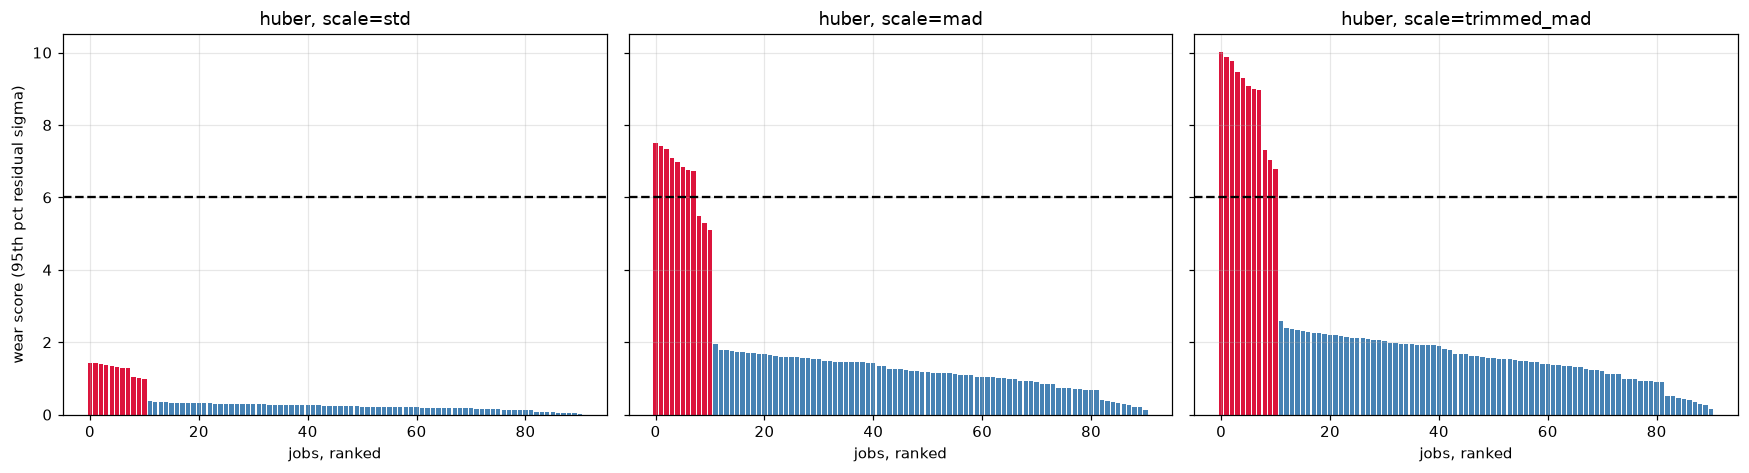

In [ ]:
# Which jobs sit either side of the 6-sigma line under each scale estimator?
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=True)
for ax, scale_name in zip(axes, ["std", "mad", "trimmed_mad"]):
    score = scale_scores[("huber", scale_name)].sort_values(ascending=False)
    colours = np.where(score.index.isin(reference_worn), "crimson", "steelblue")
    ax.bar(range(len(score)), score.to_numpy(), color=colours)
    ax.axhline(SIGMA_MULTIPLE, color="black", ls="--")
    ax.set(xlabel="jobs, ranked", title=f"huber, scale={scale_name}")
axes[0].set_ylabel("wear score (95th pct residual sigma)")
plt.tight_layout()

In [ ]:
for scale_name in ("std", "mad", "trimmed_mad"):
    score = scale_scores[("huber", scale_name)]
    worn = score[score.index.isin(reference_worn)]
    print(f"{scale_name:>12}: reference-worn jobs clearing 6 sigma = "
          f"{int((worn >= SIGMA_MULTIPLE).sum())} of {len(worn)}")

print("\nDECISION: scale_estimator = trimmed_mad.")
print("The standard deviation is inflated by the very readings we are hunting and flags")
print("almost nothing. A plain MAD is better but still contaminated, so the marginal worn")
print("jobs rank correctly yet fall just short of the bar -- a silent loss of recall that")
print("no accuracy metric on the regression would have revealed. The trimmed MAD measures")
print("the healthy population's own scatter, which is what the sigma rule assumes.")

         std: reference-worn jobs clearing 6 sigma = 0 of 11
         mad: reference-worn jobs clearing 6 sigma = 8 of 11
 trimmed_mad: reference-worn jobs clearing 6 sigma = 11 of 11

DECISION: scale_estimator = trimmed_mad.
The standard deviation is inflated by the very readings we are hunting and flags
almost nothing. A plain MAD is better but still contaminated, so the marginal worn
jobs rank correctly yet fall just short of the bar -- a silent loss of recall that
no accuracy metric on the regression would have revealed. The trimmed MAD measures
the healthy population's own scatter, which is what the sigma rule assumes.


## 11. Secondary candidates, and why `contamination` dominates everything

All three share scikit-learn's outlier-detector API (`fit`, `score_samples`, `predict`,
native `contamination`), so one loop handles any of them. `EllipticEnvelope` is a robust
Minimum Covariance Determinant fit — Mahalanobis distance from a centre and covariance
estimated on the most concentrated subset, so worn readings don't inflate the covariance
used to judge them. `LocalOutlierFactor` uses `novelty=True` so a saved model can score a
later shift.

**`contamination` is the single most consequential setting in this analysis.** Because the
two stages are combined with AND, a prior far below the true affected fraction silently
vetoes true positives. The reference set puts ~13% of cutting readings in worn jobs; at
`contamination=0.01` the pipeline flags almost nothing. Hence 0.15 — specificity is meant
to come from the 6σ primary stage, not from this threshold.

       secondary  contamination  fit_secs  flagged  precision  recall  auc_proxy  mean_score_healthy  mean_score_worn
isolation_forest           0.01    0.6902      734     0.2643  0.0206     0.9612              0.4244           0.5792
isolation_forest           0.15    0.6368    11007     0.7187  0.8412     0.9612              0.4244           0.5792
     mahalanobis           0.01    8.4008      734     0.0831  0.0065     0.9597             20.7528         157.7501
     mahalanobis           0.15    8.2897    11007     0.7532  0.8816     0.9597             20.7528         157.7501
             lof           0.01    0.6035      629     0.2989  0.0200     0.5471              1.0329           1.0555
             lof           0.15    0.5684     9814     0.2040  0.2129     0.5471              1.0329           1.0555


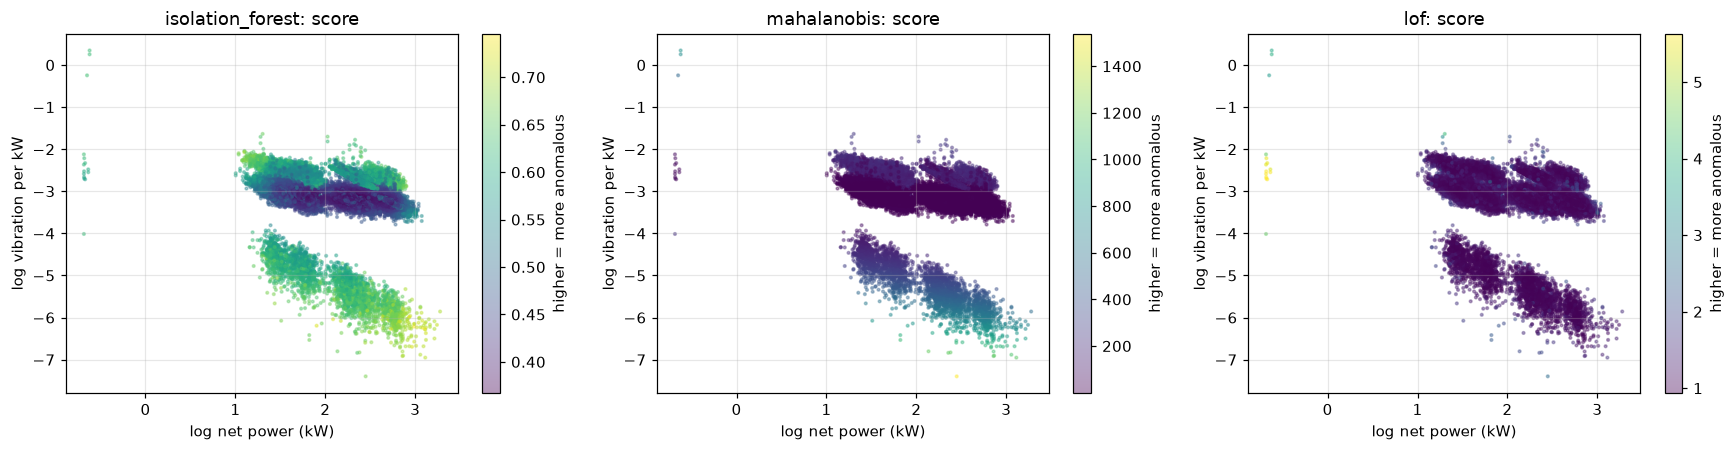

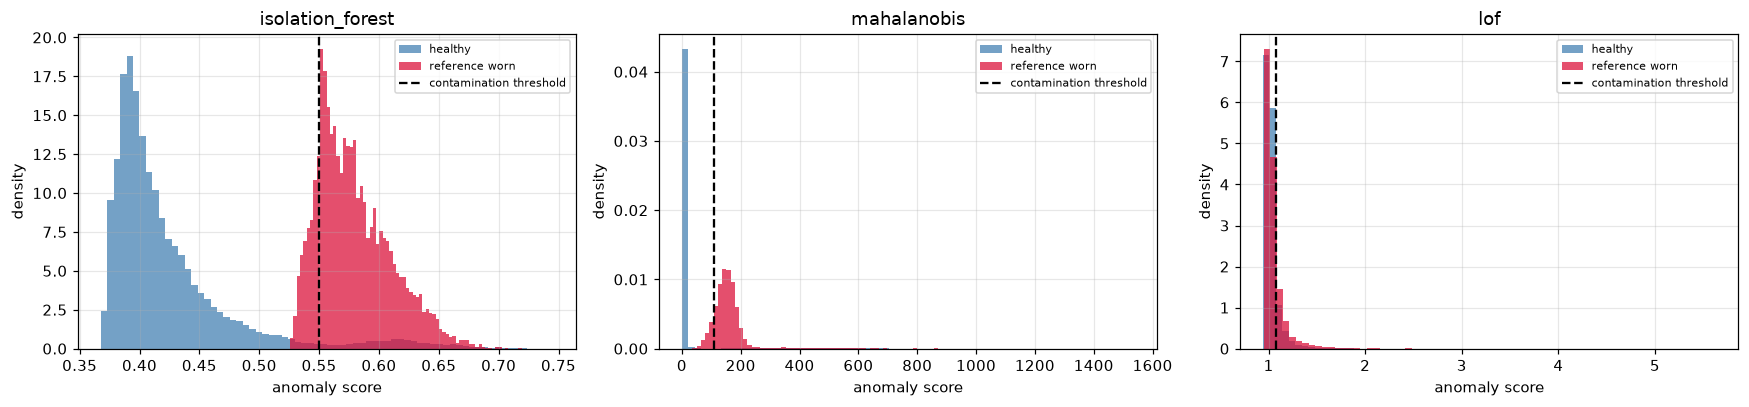

In [14]:
sec_features = cutting[SECONDARY_FEATURES]
secondary_fits, rows = {}, []

for name in ["isolation_forest", "mahalanobis", "lof"]:
    for contamination in [0.01, CONTAMINATION]:
        t0 = time.perf_counter()
        pipe = make_secondary(name, contamination).fit(sec_features)
        fit_secs = time.perf_counter() - t0
        score = -pipe.score_samples(sec_features)   # negate: higher = more anomalous
        flag = pipe.predict(sec_features) == -1     # sklearn's own contamination threshold
        secondary_fits[(name, contamination)] = {"pipe": pipe, "score": score, "flag": flag}

        # Threshold-free ranking quality: P(worn reading scores above a healthy one).
        # Computed from ranks, so it needs no extra dependency.
        ranked = pd.Series(score).rank().to_numpy()
        n_worn = int(worn_reading_mask.sum())
        n_healthy = len(score) - n_worn
        auc = (ranked[worn_reading_mask].sum() - n_worn * (n_worn + 1) / 2) / (n_worn * n_healthy)

        tp = int((flag & worn_reading_mask).sum())
        rows.append({
            "secondary": name, "contamination": contamination, "fit_secs": fit_secs,
            "flagged": int(flag.sum()),
            "precision": tp / max(int(flag.sum()), 1),
            "recall": tp / max(int(worn_reading_mask.sum()), 1),
            "auc_proxy": float(auc),
            "mean_score_healthy": float(score[~worn_reading_mask].mean()),
            "mean_score_worn": float(score[worn_reading_mask].mean()),
        })

print(pd.DataFrame(rows).round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, name in zip(axes, ["isolation_forest", "mahalanobis", "lof"]):
    score = secondary_fits[(name, CONTAMINATION)]["score"]
    sc = ax.scatter(cutting["log_net_power_kw"], cutting["log_vib_per_kw"],
                    c=score, s=3, alpha=0.4, cmap="viridis")
    ax.set(xlabel="log net power (kW)", ylabel="log vibration per kW", title=f"{name}: score")
    plt.colorbar(sc, ax=ax, label="higher = more anomalous")
plt.tight_layout()

# Score distributions: does the detector separate the two populations at all, or does it
# merely rank them? A detector can have a good AUC and still put its threshold badly.
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, name in zip(axes, ["isolation_forest", "mahalanobis", "lof"]):
    fit = secondary_fits[(name, CONTAMINATION)]
    ax.hist(fit["score"][~worn_reading_mask], bins=70, color="steelblue", alpha=0.75,
            density=True, label="healthy")
    ax.hist(fit["score"][worn_reading_mask], bins=70, color="crimson", alpha=0.75,
            density=True, label="reference worn")
    ax.axvline(np.quantile(fit["score"], 1 - CONTAMINATION), color="black", ls="--",
               label="contamination threshold")
    ax.set(xlabel="anomaly score", ylabel="density", title=name)
    ax.legend(fontsize=7)
plt.tight_layout()

In [15]:
print("LOF is the outlier here: it scores the sparse EDGES of the healthy cloud highly --")
print("low local density, but nothing to do with wear -- so its flags land in the wrong")
print("place and its AUC proxy trails the other two badly.")

LOF is the outlier here: it scores the sparse EDGES of the healthy cloud highly --
low local density, but nothing to do with wear -- so its flags land in the wrong
place and its AUC proxy trails the other two badly.


## 12. Rolling up to per-job verdicts

A reading-level flag is noisy; the deliverable is per-job. A job is flagged only when
enough of its readings are flagged by **both** stages — sustained chatter, not one
transient. Jobs with too few cutting readings get *no verdict* rather than a guess.

Per the brief: `mean_power_kw` is the job's mean power **minus that machine's idle draw**,
`peak_vibration_g` is the max peak amplitude, and the ranking uses the **primary** score only.

In [16]:
def score_readings(cutting_df, primary_fit, secondary_fit, scale="trimmed_mad"):
    '''Per-reading scores and the combined AND flag.'''
    sigma = primary_fit["sigma"] if scale == "trimmed_mad" else primary_fit["sigma_mad"]
    df = cutting_df.copy()
    df["residual_g"] = primary_fit["resid"]
    # one-sided: only EXCESS vibration indicates wear
    df["primary_score"] = (primary_fit["resid"] - primary_fit["centre"]) / sigma
    df["primary_anomalous"] = df["primary_score"] >= SIGMA_MULTIPLE
    df["secondary_score"] = secondary_fit["score"]
    df["secondary_anomalous"] = secondary_fit["flag"]
    df["anomalous"] = df["primary_anomalous"] & df["secondary_anomalous"]
    return df


def aggregate_reading_flags(scored):
    out = scored.groupby("job_id", observed=True).agg(
        cutting_readings=("primary_score", "size"),
        wear_score=("primary_score", lambda s: float(np.quantile(s, SCORE_QUANTILE))),
        max_primary_sigma=("primary_score", "max"),
        n_anomalous=("anomalous", "sum"),
        mean_vib_per_kw=("vib_per_kw", "mean"),
    ).reset_index()
    out["n_anomalous"] = out["n_anomalous"].astype(int)
    out["anomalous_fraction"] = out["n_anomalous"] / out["cutting_readings"].clip(lower=1)
    return out


def aggregate_jobs(jobs_df, power_with_jobs, vib_with_jobs, idle):
    '''Per-job power and vibration metrics, per the brief's definitions.'''
    pw = power_with_jobs[power_with_jobs["job_id"].notna()]
    power_stats = pw.groupby("job_id", observed=True).agg(
        mean_power_raw_kw=("power_kw", "mean"), power_readings=("power_kw", "size"))

    vb = vib_with_jobs[vib_with_jobs["job_id"].notna()]
    vib_stats = vb.groupby("job_id", observed=True).agg(
        peak_vibration_g=("vibration_peak_g", "max"),
        mean_vibration_rms_g=("vibration_rms_g", "mean"),
        vibration_readings=("vibration_rms_g", "size"))

    out = jobs_df.merge(power_stats, on="job_id", how="left").merge(vib_stats, on="job_id", how="left")
    out["idle_baseline_kw"] = out["machine_id"].map(idle).astype(float)
    # Mean power NET of the machine's idle draw, as the brief specifies.
    out["mean_power_kw"] = out["mean_power_raw_kw"] - out["idle_baseline_kw"]
    for c in ("power_readings", "vibration_readings"):
        out[c] = out[c].fillna(0).astype(int)
    return out


def flag_jobs(jobs_df):
    '''Final per-job verdict, rank and notes.'''
    df = jobs_df.copy()
    df["cutting_readings"] = df["cutting_readings"].fillna(0).astype(int)
    df["n_anomalous"] = df["n_anomalous"].fillna(0).astype(int)
    df["anomalous_fraction"] = df["anomalous_fraction"].fillna(0.0)

    assessable = df["cutting_readings"] >= MIN_READINGS_VERDICT
    df["assessable"] = assessable
    df["flagged"] = (assessable
                     & (df["n_anomalous"] >= MIN_ANOM_READINGS)
                     & (df["anomalous_fraction"] >= MIN_ANOM_FRACTION))

    # Rank on the primary score only. Unassessable jobs sort last rather than vanish.
    df["rank"] = (df["wear_score"].where(assessable)
                  .rank(ascending=False, method="first", na_option="bottom").astype(int))

    notes = []
    for row in df.itertuples():
        parts = [p for p in [(getattr(row, "notes", "") or "")] if p]
        if not row.assessable:
            parts.append(f"only {row.cutting_readings} cutting readings; no verdict")
        elif row.flagged:
            parts.append(f"{row.n_anomalous} of {row.cutting_readings} readings anomalous "
                         f"({100 * row.anomalous_fraction:.1f}%)")
        notes.append("; ".join(parts))
    df["notes"] = notes
    return df.sort_values("rank").reset_index(drop=True)


SPEC_COLUMNS = ["job_id", "machine_id", "mean_power_kw", "peak_vibration_g",
                "wear_score", "flagged", "rank", "notes"]


def build_job_summary(primary_name, secondary_name, contamination=CONTAMINATION,
                      scale="trimmed_mad"):
    scored = score_readings(cutting, primary_fits[primary_name],
                            secondary_fits[(secondary_name, contamination)], scale)
    jobs = aggregate_jobs(log, power, vib, idle_baseline)
    jobs = jobs.merge(aggregate_reading_flags(scored), on="job_id", how="left")
    jobs = flag_jobs(jobs)
    summary = jobs[SPEC_COLUMNS].copy()
    summary["flagged"] = np.where(jobs["flagged"], "true", "false")
    for c in ("mean_power_kw", "peak_vibration_g", "wear_score"):
        summary[c] = summary[c].round(4)
    return scored, jobs, summary


# The full grid: primary x scale x secondary x contamination, judged at the job level.
grid = []
for p_name in primary_fits:
    for scale_name in ["mad", "trimmed_mad"]:
        for (s_name, contamination) in secondary_fits:
            _, jobs_g, _ = build_job_summary(p_name, s_name, contamination, scale_name)
            flagged = set(jobs_g.loc[jobs_g["flagged"], "job_id"])
            tp = len(flagged & reference_worn)
            grid.append({"primary": p_name, "scale": scale_name, "secondary": s_name,
                         "contamination": contamination, "flagged": len(flagged), "tp": tp,
                         "fp": len(flagged - reference_worn),
                         "fn": len(reference_worn - flagged),
                         "f1": 2 * tp / max(len(flagged) + len(reference_worn), 1)})

grid_table = pd.DataFrame(grid)
print(f"{len(grid_table)} combinations evaluated\n")
print(grid_table.sort_values(["f1", "fp", "tp"], ascending=[False, True, False])
      .head(12).round(3).to_string(index=False))

print("\nEffect of the contamination prior (mean over all primaries and secondaries):")
print(grid_table[grid_table["scale"] == "trimmed_mad"]
      .groupby("contamination")[["flagged", "tp", "fp", "fn"]].mean().round(2).to_string())
print("\nEffect of the scale estimator (at the chosen contamination):")
print(grid_table[grid_table["contamination"] == CONTAMINATION]
      .groupby("scale")[["flagged", "tp", "fp", "fn"]].mean().round(2).to_string())
print(f"\nfalse positives across the entire grid: {grid_table['fp'].sum()}")
print("\nAt contamination 0.01 the secondary stage vetoes almost everything the physics")
print("found; at 0.15 -- just above the ~13% affected fraction measured in section 6 -- the")
print("two stages agree. The prior, and then the scale estimator, dominate the choice of")
print("regressor and of detector entirely.")

36 combinations evaluated

primary       scale        secondary  contamination  flagged  tp  fp  fn    f1
  huber trimmed_mad isolation_forest           0.15       11  11   0   0 1.000
  huber trimmed_mad      mahalanobis           0.15       11  11   0   0 1.000
  huber trimmed_mad              lof           0.15       11  11   0   0 1.000
 ransac trimmed_mad isolation_forest           0.15       11  11   0   0 1.000
 ransac trimmed_mad      mahalanobis           0.15       11  11   0   0 1.000
  huber         mad isolation_forest           0.15        8   8   0   3 0.842
  huber         mad      mahalanobis           0.15        8   8   0   3 0.842
  huber         mad              lof           0.15        7   7   0   4 0.778
 ransac         mad isolation_forest           0.15        7   7   0   4 0.778
 ransac         mad      mahalanobis           0.15        7   7   0   4 0.778
 ransac         mad              lof           0.15        7   7   0   4 0.778
 ransac trimmed_mad      

top 15 jobs by huber wear score:
         ridge   huber  ransac  reference_worn
job_id                                        
JOB-120  4.534  10.009   9.338            True
JOB-104  4.561   9.891   9.454            True
JOB-206  6.320   9.763   8.918            True
JOB-024  6.001   9.451   8.690            True
JOB-224  5.540   9.303   9.218            True
JOB-210  5.162   9.091   8.688            True
JOB-106  3.776   9.008   7.590            True
JOB-007  4.670   8.956   8.132            True
JOB-018  4.021   7.304   6.650            True
JOB-032  3.667   7.046   6.343            True
JOB-040  3.402   6.786   6.119            True
JOB-212  2.975   2.600   2.467           False
JOB-202  2.051   2.383   2.116           False
JOB-217  2.546   2.364   2.127           False
JOB-216  2.246   2.334   2.147           False

Spearman correlation between the primaries' job rankings:
         ridge   huber  ransac
ridge   1.0000  0.6948  0.7115
huber   0.6948  1.0000  0.9716
ransac  0.7115  

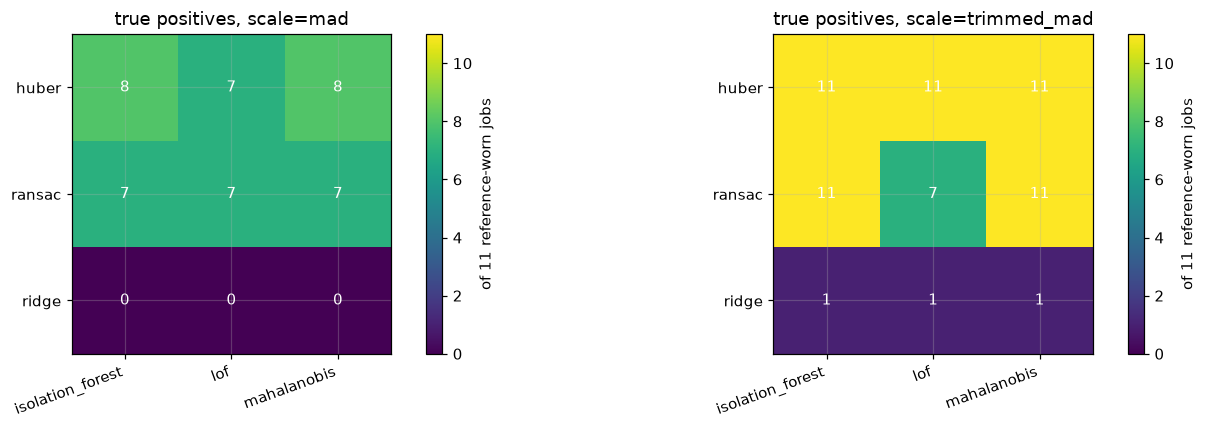

In [17]:
# Where the true positives live: primary x secondary, one panel per scale estimator.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
for ax, scale_name in zip(axes, ["mad", "trimmed_mad"]):
    piv = (grid_table[(grid_table["scale"] == scale_name)
                      & (grid_table["contamination"] == CONTAMINATION)]
           .pivot(index="primary", columns="secondary", values="tp"))
    im = ax.imshow(piv.to_numpy(dtype=float), cmap="viridis",
                   vmin=0, vmax=len(reference_worn))
    ax.set(xticks=range(piv.shape[1]), yticks=range(piv.shape[0]),
           title=f"true positives, scale={scale_name}")
    ax.set_xticklabels(piv.columns, rotation=20, ha="right")
    ax.set_yticklabels(piv.index)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, int(piv.to_numpy()[i, j]), ha="center", va="center", color="white")
    plt.colorbar(im, ax=ax, label=f"of {len(reference_worn)} reference-worn jobs")
plt.tight_layout()


# Does the RANKING survive the model choice? That is what we actually ship.
rank_scores = {}
for p_name in primary_fits:
    _, jobs_r, _ = build_job_summary(p_name, "mahalanobis")
    rank_scores[p_name] = jobs_r.set_index("job_id")["wear_score"]

ranks = pd.DataFrame(rank_scores)
ranks["reference_worn"] = ranks.index.isin(reference_worn)
print("top 15 jobs by huber wear score:")
print(ranks.sort_values("huber", ascending=False).head(15).round(3).to_string())
print("\nSpearman correlation between the primaries' job rankings:")
print(ranks[["ridge", "huber", "ransac"]].corr(method="spearman").round(4).to_string())

## 13. Recommendation and results

**Primary: `HuberRegressor`. Secondary: `EllipticEnvelope` (robust Mahalanobis). Log
target, trimmed-MAD scale, `contamination=0.15`.**

*Primary.* RANSAC scores marginally better on separation margin, but Huber is
**deterministic** — RANSAC's random subset draws could settle on a different consensus set
on a held-out shift — it **uses all the data** via smooth downweighting rather than hard
discarding, and it is cheap. Ridge is rejected: not robust, worst margin, and its baseline
is visibly pulled toward the worn population.

*Secondary.* `EllipticEnvelope` over `IsolationForest` because the healthy cloud in log
space is a compact ellipsoid — precisely its modelling assumption — and it is
deterministic, has no tree-depth or subsample hyperparameters to transfer, and is far
cheaper. LOF is rejected on substance: it flags the low-density *edges* of the healthy
cloud, which is not the same thing as wear.

*Confidence.* High on the **ranking**, moderate on the **cut-off**. Three independent lines
of evidence agree: the relative-vibration distribution is bimodal with an empty gap, the
crest factor separates the same jobs perfectly, and every model family puts the same jobs
on top with zero false positives anywhere in the grid. The 6σ threshold, by contrast, is a
choice about false-positive tolerance, not an estimated quantity.

*What would raise it:* maintenance and tool-change records to convert this into supervised
validation; spindle load or feed/speed to separate a dull tool from an aggressive program;
several shifts, to watch wear trend within a tool's life.

In [18]:
scored, jobs, job_summary = build_job_summary("huber", "mahalanobis")

fit = primary_fits["huber"]
print(f"primary=huber secondary=mahalanobis sigma={fit['sigma']:.4f} "
      f"(plain sd {fit['resid'].std():.4f})")
print(f"readings: {len(scored):,} scored | primary {int(scored['primary_anomalous'].sum()):,} "
      f"| secondary {int(scored['secondary_anomalous'].sum()):,} "
      f"| both {int(scored['anomalous'].sum()):,}")
print(f"jobs: {len(jobs)} total | {int(jobs['flagged'].sum())} flagged "
      f"| {int((~jobs['assessable']).sum())} not assessable")
print(f"agreement with the derived reference set: "
      f"{len(set(jobs.loc[jobs['flagged'], 'job_id']) & reference_worn)} of {len(reference_worn)}")

print("\n" + job_summary.head(15).to_string(index=False))

# The decision margin: worst flagged vs best unflagged.
assessable = jobs[jobs["assessable"]]
worst_flagged = assessable.loc[assessable["flagged"], "wear_score"].min()
best_clear = assessable.loc[~assessable["flagged"], "wear_score"].max()
print(f"\ndecision margin: worst flagged {worst_flagged:.3f} vs best unflagged {best_clear:.3f} "
      f"({worst_flagged / max(best_clear, 1e-9):.1f}x around the {SIGMA_MULTIPLE:.0f}-sigma line)")


primary=huber secondary=mahalanobis sigma=0.0687 (plain sd 0.4782)
readings: 73,379 scored | primary 7,488 | secondary 11,007 | both 6,570
jobs: 94 total | 11 flagged | 3 not assessable
agreement with the derived reference set: 11 of 11

 job_id machine_id  mean_power_kw  peak_vibration_g  wear_score flagged  rank                                                   notes
JOB-120     CNC-09         5.3291            3.1401     10.0085    true     1                 1255 of 1414 readings anomalous (88.8%)
JOB-104     CNC-09        14.1518            6.4894      9.8914    true     2                 1157 of 1275 readings anomalous (90.7%)
JOB-206     CNC-11        10.5845            4.9902      9.7628    true     3                   255 of 345 readings anomalous (73.9%)
JOB-024     CNC-07         9.2635            6.9303      9.4506    true     4                   264 of 386 readings anomalous (68.4%)
JOB-224     CNC-11         5.4966            3.2548      9.3031    true     5               

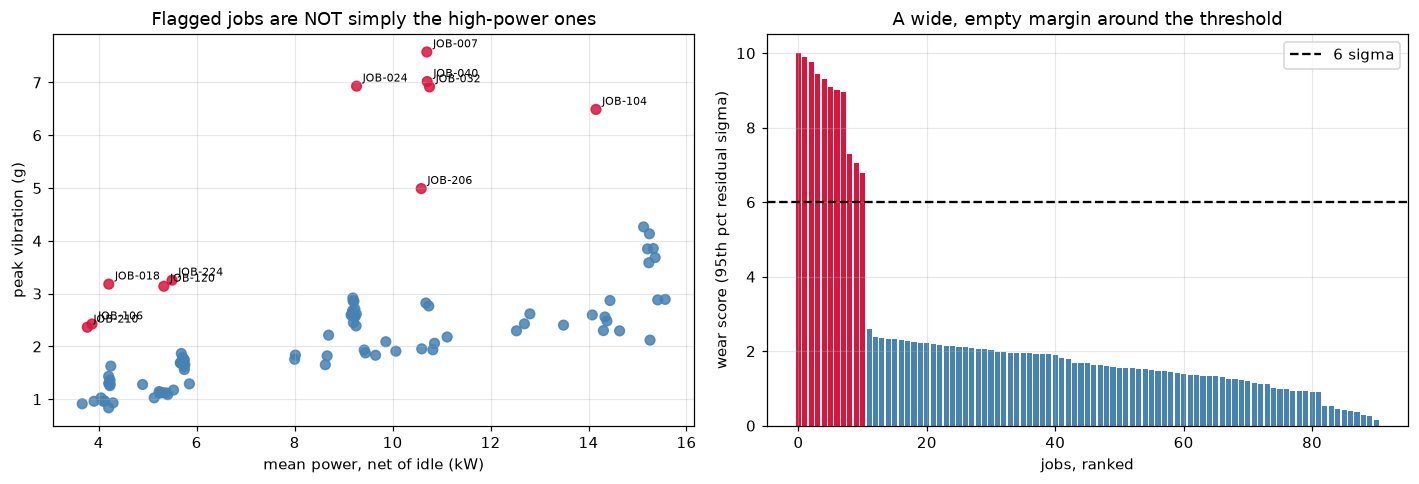

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colours = np.where(jobs["flagged"], "crimson", "steelblue")
axes[0].scatter(jobs["mean_power_kw"], jobs["peak_vibration_g"], c=colours, s=40, alpha=0.85)
for row in jobs[jobs["flagged"]].itertuples():
    axes[0].annotate(row.job_id, (row.mean_power_kw, row.peak_vibration_g),
                     fontsize=7, xytext=(4, 3), textcoords="offset points")
axes[0].set(xlabel="mean power, net of idle (kW)", ylabel="peak vibration (g)",
            title="Flagged jobs are NOT simply the high-power ones")

order = jobs[jobs["assessable"]].sort_values("wear_score", ascending=False)
axes[1].bar(range(len(order)), order["wear_score"],
            color=np.where(order["flagged"], "crimson", "steelblue"))
axes[1].axhline(SIGMA_MULTIPLE, color="black", ls="--", label=f"{SIGMA_MULTIPLE:.0f} sigma")
axes[1].set(xlabel="jobs, ranked", ylabel="wear score (95th pct residual sigma)",
            title="A wide, empty margin around the threshold")
axes[1].legend()
plt.tight_layout()

In [20]:
# Reading-level metrics are not the deliverable. Roll each primary up to a per-job wear
# score and ask whether the RANKED LIST -- what we actually ship -- depends on the regressor.
job_sep = []
for name, fit in primary_fits.items():
    per_job = (pd.DataFrame({"job_id": cutting["job_id"], "z": fit["z"]})
               .groupby("job_id", observed=True)["z"].quantile(SCORE_QUANTILE))
    is_worn = per_job.index.isin(reference_worn)
    top_n = set(per_job.sort_values(ascending=False).head(len(reference_worn)).index)
    healthy_max, worn_min = float(per_job[~is_worn].max()), float(per_job[is_worn].min())
    job_sep.append({
        "primary": name,
        "healthy_max": healthy_max, "worn_min": worn_min,
        "margin": worn_min - healthy_max,
        "ratio": worn_min / max(healthy_max, 1e-9),
        "reference_in_top_n": len(top_n & reference_worn),
        "n_reference": len(reference_worn),
    })

print("Job-level separation (wear score = 95th percentile of residual sigma):")
print(pd.DataFrame(job_sep).round(3).to_string(index=False))
print("\nIf reference_in_top_n equals n_reference for every regressor, the ranking is")
print("insensitive to that choice and only the absolute sigma scale -- and therefore the")
print("binary flag -- moves. That is what makes the ranked list the robust deliverable")
print("and the threshold the tunable part.")

Job-level separation (wear score = 95th percentile of residual sigma):
primary  healthy_max  worn_min  margin  ratio  reference_in_top_n  n_reference
  ridge        2.975     3.402   0.428  1.144                  11           11
  huber        2.600     6.786   4.186  2.610                  11           11
 ransac        2.649     6.119   3.470  2.310                  11           11

If reference_in_top_n equals n_reference for every regressor, the ranking is
insensitive to that choice and only the absolute sigma scale -- and therefore the
binary flag -- moves. That is what makes the ranked list the robust deliverable
and the threshold the tunable part.


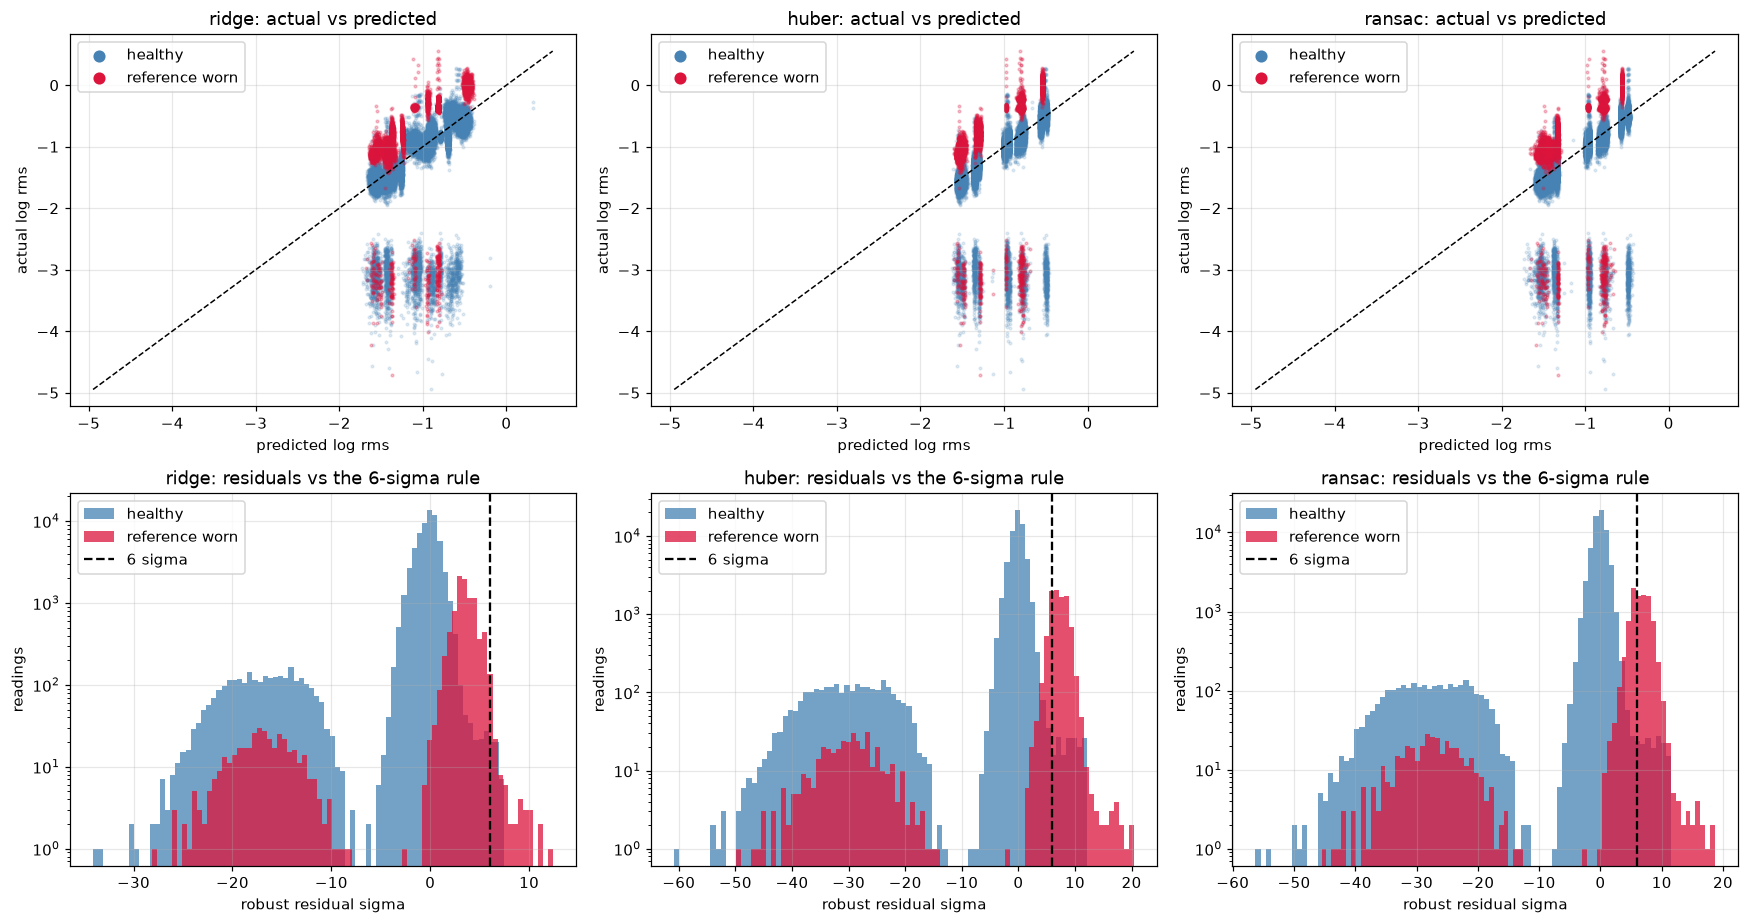

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
for col, (name, fit) in enumerate(primary_fits.items()):
    pred = y - fit["resid"]
    ax = axes[0, col]
    ax.scatter(pred[~worn_reading_mask], y[~worn_reading_mask], s=3, alpha=0.15,
               color="steelblue", label="healthy")
    ax.scatter(pred[worn_reading_mask], y[worn_reading_mask], s=3, alpha=0.25,
               color="crimson", label="reference worn")
    lims = [min(pred.min(), y.min()), max(pred.max(), y.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set(xlabel="predicted log rms", ylabel="actual log rms", title=f"{name}: actual vs predicted")
    leg = ax.legend(markerscale=4, loc="upper left")
    for h in leg.legend_handles:
        h.set_alpha(1.0)

    ax = axes[1, col]
    ax.hist(fit["z"][~worn_reading_mask], bins=80, color="steelblue", alpha=0.75, label="healthy")
    ax.hist(fit["z"][worn_reading_mask], bins=80, color="crimson", alpha=0.75, label="reference worn")
    ax.axvline(SIGMA_MULTIPLE, color="black", ls="--", label=f"{SIGMA_MULTIPLE:.0f} sigma")
    ax.set(xlabel="robust residual sigma", ylabel="readings", yscale="log",
           title=f"{name}: residuals vs the 6-sigma rule")
    ax.legend()
plt.tight_layout()